# Hydrosheds

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [81]:
import os
import fiona
import geopandas as gpd

from src.datasources import hydrosheds, codab
from src.constants import *

In [61]:
adm3 = codab.load_codab(admin_level=3, aoi_only=True)

In [ ]:
gdf = hydrosheds.load_all_rivers()

In [ ]:
gdf_1 = gdf[gdf["ORD_CLAS"] == 1]

In [57]:
gdf_2 = gdf[gdf["ORD_CLAS"] <= 2]

In [48]:
gdf_1_0 = gdf_1[gdf_1["NEXT_DOWN"] == 0]

In [49]:
gdf_1_0.sort_values("DIST_UP_KM", ascending=False)

,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,ORD_STRA,ORD_CLAS,ORD_FLOW,HYBAS_L12,geometry
47862,10047863,0,10047863,5.20,0.0,6846.5,29.49,2916802.0,0,1934.082,8,1,3,1120034260,"LINESTRING (30.43125 31.42708, 30.41875 31.439..."
1137694,11137695,0,11137695,2.96,0.0,4964.1,7.68,3705302.0,0,39636.766,9,1,2,1120020040,"LINESTRING (12.48958 -6.06458, 12.48542 -6.068..."
877686,10877687,0,10877687,4.28,0.0,4254.2,8.35,2098664.0,0,6858.671,8,1,3,1120022420,"LINESTRING (6.05208 4.42292, 6.05208 4.41042, ..."
1371099,11371100,0,11371100,11.45,0.0,3151.9,44.31,1378121.0,0,3896.153,8,1,3,1120011660,"LINESTRING (36.23542 -18.71875, 36.24375 -18.7..."
1493633,11493634,0,11493634,8.12,0.0,2542.2,34.68,884882.9,0,309.776,9,1,4,1120015850,"LINESTRING (16.48958 -28.57292, 16.47708 -28.5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689829,10689830,0,10689830,0.98,0.0,1.8,1.91,1.7,0,0.120,1,1,7,1120025370,"LINESTRING (-13.04583 8.62500, -13.05208 8.63125)"
692440,10692441,0,10692441,0.69,0.0,1.8,2.33,2.1,0,0.149,1,1,7,1120025370,"LINESTRING (-13.13333 8.56875, -13.12708 8.56875)"
1325180,11325181,0,11325181,0.96,0.0,1.8,2.47,2.3,0,0.158,1,1,7,1120038750,"LINESTRING (49.76667 -16.66250, 49.77292 -16.6..."
1330513,11330514,0,11330514,0.67,0.0,1.7,1.85,1.6,0,0.119,1,1,7,1120038780,"LINESTRING (49.88333 -16.88958, 49.87708 -16.8..."


In [67]:
gdf_niger_only = gdf_1[gdf_1["MAIN_RIV"] == NIGER_MAINRIVER_ID]

<Axes: >

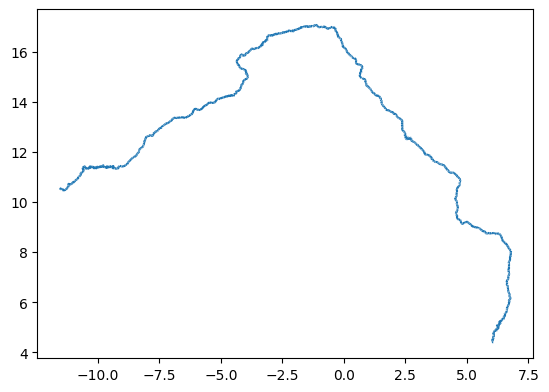

In [68]:
gdf_niger_only.plot()

In [83]:
filename = "niger_river"
save_dir = hydrosheds.HS_PROC_DIR / filename
if not save_dir.exists():
    os.makedirs(save_dir)
gdf_niger_only.to_file(
    hydrosheds.HS_PROC_DIR / filename / f"{filename}.shp",
    driver="ESRI Shapefile",
)

In [64]:
gdf_niger = gdf[gdf["MAIN_RIV"] == NIGER_MAINRIVER_ID]

<Axes: >

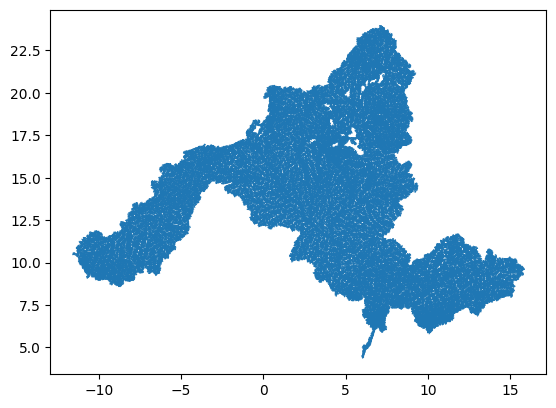

In [66]:
gdf_niger.plot()

In [82]:
filename = "niger_system_rivers"
save_dir = hydrosheds.HS_PROC_DIR / filename
if not save_dir.exists():
    os.makedirs(save_dir)
gdf_niger.to_file(
    hydrosheds.HS_PROC_DIR / filename / f"{filename}.shp",
    driver="ESRI Shapefile",
)

In [76]:
niger_aoi = gpd.sjoin(
    gdf_niger_only, adm3, how="inner", predicate="intersects"
)

<Axes: >

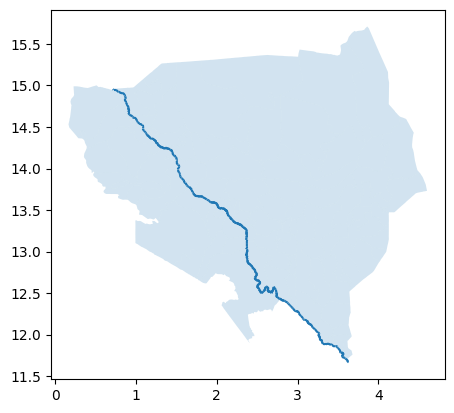

In [77]:
ax = adm3.plot(alpha=0.2)
niger_aoi.plot(ax=ax)